# Programming & Scripting Project

### Step 1: Importing the dataset & packages

In [1]:
# Importing the data required for analyis, using the sklearn method as demonstrated here [1]: https://www.geeksforgeeks.org/machine-learning/iris-dataset/
from sklearn.datasets import load_iris

# Importing the packages required for analysis - I used these to analyse my project for Principles of Data Analytics and feel they will be useful again in this project [2] https://www.kaggle.com/code/chats351/introduction-to-numpy-pandas-and-matplotlib:
import pandas as pd
# Statistical data evaluation.
import matplotlib.pyplot as plt
# More sophistacted graphs
import seaborn as sns

### Step 2: Loading the Dataset & Viewing the Structure

In [2]:
# Loading in the dataset and viewing the structure

# Load the Iris Dataset
iris = load_iris()

# Create a dataframe from the data
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add the species column
df["species"] = iris.target

# Replace numeric species labels with names (used Co-Pilot to assist with this code [3] https://m365.cloud.microsoft/chat/conversation/65ae90ff-4d61-47e2-b093-b198808eb3a8?fromcode=cmc&redirectid=F5803B0A7CBC44BDBA083BAF6C6562EA&auth=2&internalredirect=CCM&client-request-id=bed92ccf-3ca5-4170-ba9f-eb3cc07f77a2&origindomain=CCM&login_hint=leah.curran1%40abbott.com)
df["species"] = df["species"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
}) 

In [3]:
# Verifying what I've done has loaded correctly
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
# Viewing the data structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
# Checking the distribution of the species to ensure we have an even data split (code from here: https://github.com/THAMIZH-ARASU/Exploratory-Data-Analysis-on-The-Iris-Data-Set/blob/main/iris_exploration.ipynb )
print("\nDistribution of species:")
print(df['species'].value_counts())


Distribution of species:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


*df.head()* shows the first five rows of the dataset, confirming that the four variables and the species label were loaded correctly from my code above.
*df.info()* confirms that the dataset contains 150 entries and no missing values, all the columns are floats / numerical which makes them suitable for my planned analysis and plotting.

### Step 3: Summary of each Variable 

Here I'll generate summary statistics for each variable in the dataset to describe the values and spread of the data measured. The output will be saved to a txt file for reference. 

First I'll deal with the numerical variables using the describe function.

In [6]:
# Selecting only the numerical columns
numeric_df = df.drop(columns=["species"])

# Generate the summary statistics
# Adding in rounding to make the data tidier (using this as a reference: [4] https://stackoverflow.com/questions/72862898/round-df-describe-results)
summary = numeric_df.describe().round(2)

summary

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


From this summary I can note that petal length and width have noticeably larger standard deviations than the sepal measurements, indicating a greater variation in size which may be more useful than sepal length when distunguishing between species for further analysis.

In [7]:
# Creating a folder for the summary file (referencing [5] https://docs.python.org/3/library/os.html#files-and-directories)
import os 
os.makedirs("output", exist_ok=True)

In [8]:
# Write the summary statistics to a text file (referencing [6] https://www.w3schools.com/python/python_file_write.asp)
with open ("output/summaries.txt","w") as file:
    file.write("summary-stats-iris\n\n")
    file.write(summary.to_string())

Above I've created an output directory to store my generated files and images produced.

### Step 4: Histograms 

Using histograms here will allow me to see the distribution of each numerical variable in the Iris dataset - or the range, spread and shape of the data. This is similar to the approach taken in my Palmer Penguins project, so I will use some of this [code](https://github.com/leahchristina/principles-of-data-analytics-atu/blob/main/problems.ipynb?short_path=5786465) as reference.

In [9]:
# Creating a folder for my histogram images
import os

os.makedirs("output/histograms", exist_ok=True)

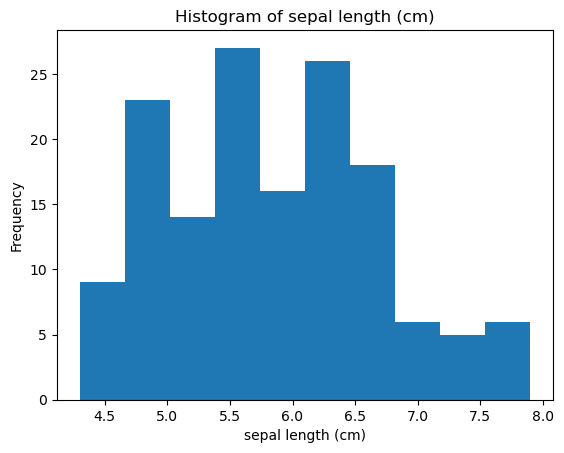

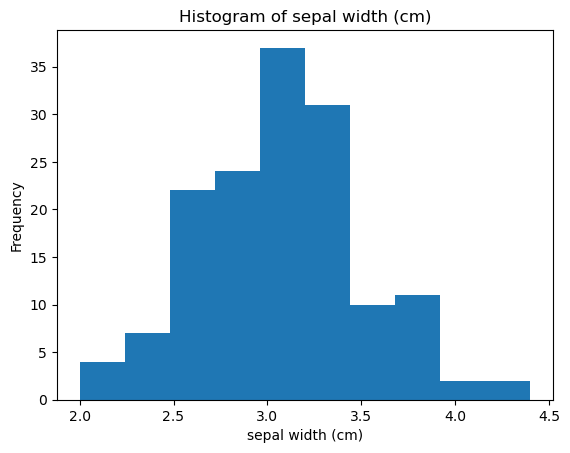

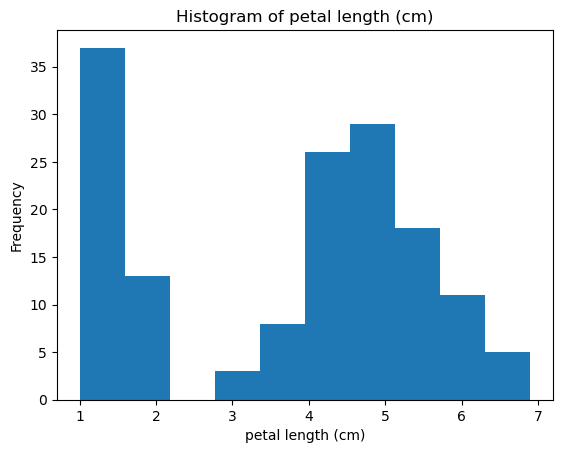

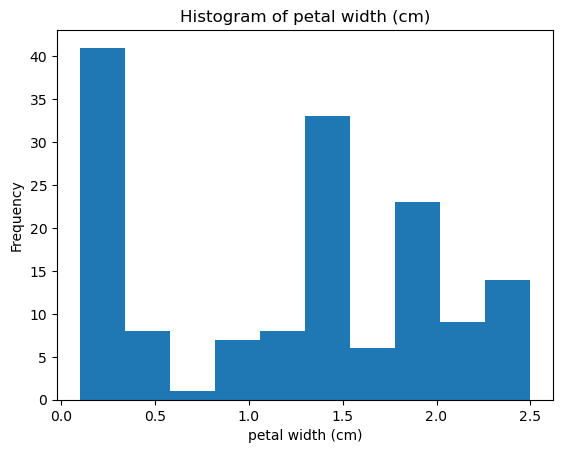

In [10]:
# Loop through each numerical column and create a histogram (referencing: [7] https://realpython.com/python-histograms/ & [8] https://www.w3schools.com/python/python_for_loops.asp)
for column in numeric_df.columns:
    plt.figure()
    plt.hist(numeric_df[column], bins=10)
    plt.title(f"Histogram of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    
    # Save the figure
    plt.savefig(f"output/histograms/{column}_histogram.png")
    
    # Display the figure
    plt.show()

My histograms match my analysis of the summary variables - showing tightly clustered measurements for the sepal measurements and a more wide distribution for the petal lengths suggesting a wider variability here. 

### Step 5: Scatter Plots

Scatter plots will allow me to examine the relationsip between the variables and how or if each pair of variables can help predict the different Iris species.

In [11]:
# Create a folder for scatter plot images
import os

os.makedirs("output/scatter-plots", exist_ok=True)

In [12]:
# Define colours for each species (https://matplotlib.org/stable/gallery/color/named_colors.html)
species_colours = {
    "setosa": "violet",
    "versicolor": "darkseagreen",
    "virginica": "lightskyblue"
}

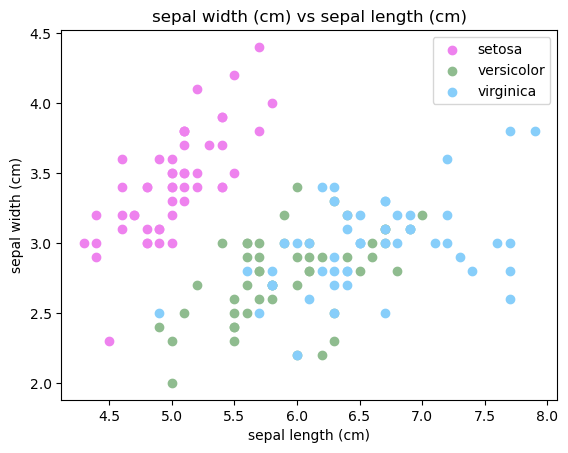

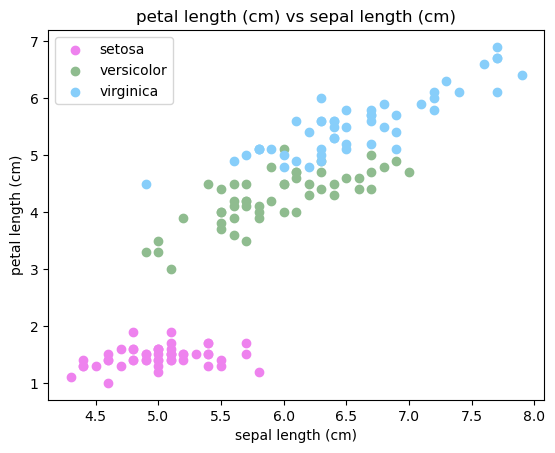

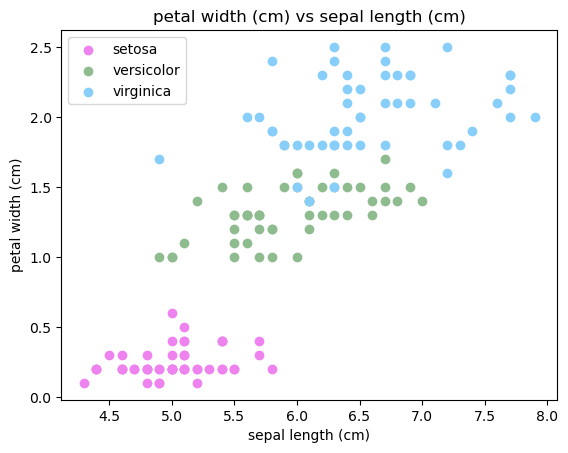

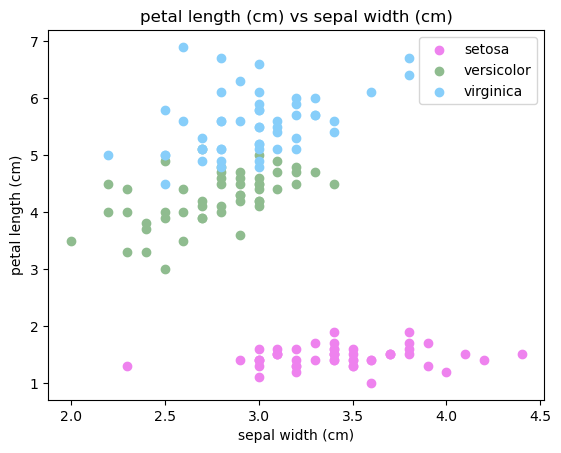

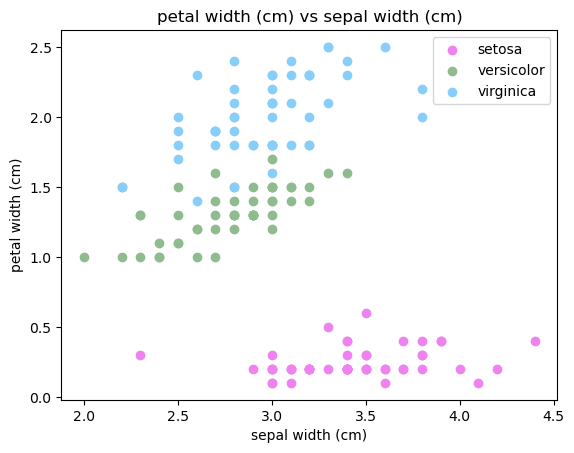

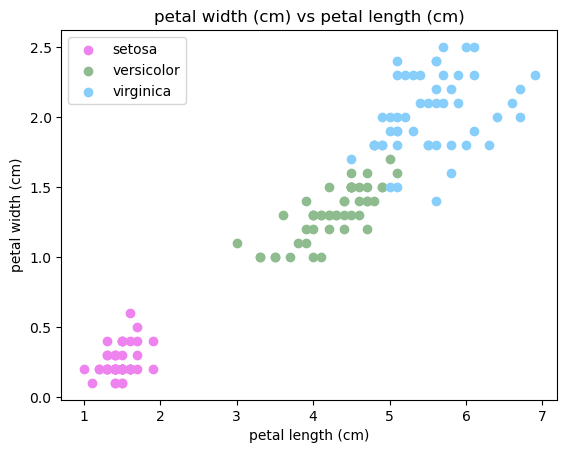

In [13]:
# Create and save the scatter plots for each pair of variables (reference code: https://www.w3schools.com/python/matplotlib_scatter.asp & https://www.youtube.com/watch?v=pTjsr_0YWas)
# Get the numerical column names
columns = numeric_df.columns

# Loop over each pair of variables
for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        x_col = columns[i]
        y_col = columns[j]
        
        plt.figure()
        
        # Plot each species separately
        for species, colour in species_colours.items():
            subset = df[df["species"] == species]
            plt.scatter(subset[x_col], subset[y_col], label=species, color=colour)
        
        plt.xlabel(x_col)
        plt.ylabel(y_col)
        plt.title(f"{y_col} vs {x_col}")
        plt.legend()
        
        # Save and display the plot
        plt.savefig(f"output/scatter-plots/{y_col}_vs_{x_col}.png")
        plt.show()


The scatter plots show that petal length and width provide clear separation between the three species, espcially for the setosa. In contrast, the sepal charts feature more overlapping data points.

### Step 6: Other Analysis

For other analysis, I've chosen to do histograms in order to see the spread of each variable and understand the impact of any outliers.

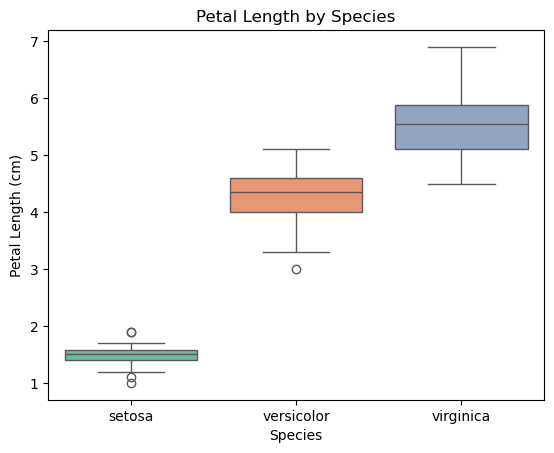

In [14]:
# Plotting Histogram (using some code from my previous project: https://github.com/leahchristina/principles-of-data-analytics-atu)
# Added Seaborn after seeing it's use in this repository to make my graphs look nicer (https://github.com/THAMIZH-ARASU/Exploratory-Data-Analysis-on-The-Iris-Data-Set/blob/main/iris_exploration.ipynb): 
# Ran into a warning here for running palette without a hue which I didn't really understand, Co-Pilot convo: https://m365.cloud.microsoft/chat/conversation/f9e41e78-bf8b-4393-a976-595c17294c27?fromCode=cmcv2&redirectId=2CC80BEE2E514789B7C4F026BAC483AD&login_hint=leah.curran1%40abbott.com&internalredirect=CCM&client-request-id=bed92ccf-3ca5-4170-ba9f-eb3cc07f77a2&origindomain=CCM

plt.figure()
sns.boxplot(
    data=df,
    x="species",
    y="petal length (cm)",
    hue="species",
    palette="Set2",
    legend=False
)

plt.title("Petal Length by Species")
plt.xlabel("Species")
plt.ylabel("Petal Length (cm)")
plt.show()


The histogram supports my earlier conclusion of minimal outliers for iris setosa - that petal length is a strong distinguishing feature. Here we can also see the spread of variables for iris virginica which matches the variability in the scatter plot points.

# Conclusion